In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Any, Callable, Optional, Union

# Data Pipeline for ResNet-18

In [2]:
import torchvision
import torchvision.transforms as transforms


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010)),
])

In [4]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010)),
])

 The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. 

In [5]:
trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform_train)

testset  = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_test)

/home/aayaanhasnain/Workspace/ResNet/.venv/lib64/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
len(trainset), len(testset)

(50000, 10000)

In [7]:
trainloader = torch.utils.data.DataLoader(dataset=trainset, batch_size=128, shuffle=True)
testloader  = torch.utils.data.DataLoader(dataset=testset, batch_size=100, shuffle=False)

## Visualization

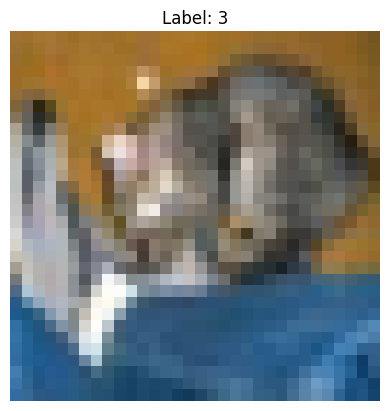

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# get one batch
images, labels = next(iter(testloader))  # images: (B, C, H, W), labels: (B,)

img = images[0]  # first image (C, H, W)

# unnormalize
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])

img = img.numpy().transpose((1, 2, 0))  # C,H,W → H,W,C
img = std * img + mean
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

# ResNet18 Architecture

In [9]:
def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    # 3x3 conv with padding
    return nn.Conv2d(
        in_channels=in_planes, 
        out_channels=out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation
    )

In [10]:
def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    # 1x1 conv 
    return nn.Conv2d(
        in_channels=in_planes,
        out_channels=out_planes,
        kernel_size=1,
        stride=stride,
        bias=False
    )

In [11]:
class BasicBlock(nn.Module):
    expansion: int = 1
    
    def __init__(
        self, 
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
    ) -> None:
        super().__init__()
        
        norm_layer = nn.BatchNorm2d
        
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x   
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = self.relu(out)
        
        return out

In [13]:
from functools import partial
from typing import Any, Callable, Optional, Union

In [14]:
class ResNet(nn.Module):
    def __init__(
        self,
        block: type[Union[BasicBlock, Bottleneck]], 
        layers: list[int],
        num_classes: int = 10,
        groups: int = 1,
        width_per_group: int = 64,
    ) -> None:
        super().__init__()
        norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer
        
        self.inplanes = 64
        self.dilation = 1
        
        self.groups = groups
        self.base_width = width_per_group
        
        # Original implementation had k=7, s=2, p=3 for STEM layer
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=self.inplanes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1  = nn.BatchNorm2d(num_features=self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        
        self.layer1 = self._make_layer(block=block, planes=64, blocks=layers[0])
        self.layer2 = self._make_layer(block=block, planes=128, stride=2, blocks=layers[1])
        self.layer3 = self._make_layer(block=block, planes=256, stride=2, blocks=layers[2])
        self.layer4 = self._make_layer(block=block, planes=512, stride=2, blocks=layers[3])
        
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
    
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def _make_layer(
        self,
        block: type[Union[BasicBlock, Bottleneck]],
        planes: int, 
        blocks: int,
        stride: int=1,
    ) -> nn.Sequential:
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )
            
        layers = []
        layers.append(
            block(
                self.inplanes,
                planes=planes,
                stride=stride,
                downsample=downsample,
                groups=self.groups,
                base_width=self.base_width,
                dilation=previous_dilation,
            )
        )
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes=planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                )
            )
        
        return nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        # x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        
        return x

In [15]:
def resnet18():
    return ResNet(block=BasicBlock, layers=[2, 2, 2, 2])

# Training ResNet-18

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [17]:
import torch.optim as optim
import time

In [18]:
model = resnet18().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# epochs = 200 
epochs = 1 

print(f"Starting training on {device}...")

for epoch in range(epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()  # enable BatchNorm tracking
    train_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        # Move data to GPU
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Zero the gradients from the previous step
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass (compute gradients)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_acc = 100. * correct / total
    avg_train_loss = train_loss / len(trainloader)
    
    # --- EVALUATION PHASE ---
    model.eval()  # Set model to evaluation mode (freezes BatchNorm)
    test_loss = 0.0
    correct = 0
    total = 0
    
    # Disable gradient calculation for testing to save memory and compute
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    test_acc = 100. * correct / total
    avg_test_loss = test_loss / len(testloader)
    
    # Step the learning rate scheduler
    scheduler.step()
    
    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)
    
    # Print epoch results
    print(f"Epoch: {epoch+1:03d}/{epochs} | Time: {epoch_mins}m {epoch_secs}s | "
          f"LR: {scheduler.get_last_lr()[0]:.5f}")
    print(f"\tTrain Loss: {avg_train_loss:.3f} | Train Acc: {train_acc:.2f}%")
    print(f"\tTest Loss:  {avg_test_loss:.3f} | Test Acc:  {test_acc:.2f}%")

print("Training Complete!")

Starting training on cuda...
Epoch: 001/1 | Time: 1m 19s | LR: 0.09999
	Train Loss: 1.915 | Train Acc: 30.51%
	Test Loss:  1.602 | Test Acc:  40.61%
Training Complete!


# ResNet-50

In [19]:
class Bottleneck(nn.Module):
    expansion: int = 4
    
    def __init__(
        self, 
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
    ) -> None:
        super().__init__()
        
        norm_layer = nn.BatchNorm2d
        
        width = int(planes * (base_width / 64.)) * groups
        
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x   
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = self.relu(out)
        
        return out

In [20]:
def resnet50():
    return ResNet(block=Bottleneck, layers=[3, 4, 6, 3])

In [ ]:
model = resnet50().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# epochs = 200 
epochs = 1 

print(f"Starting training on {device}...")

for epoch in range(epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()  # enable BatchNorm tracking
    train_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        # Move data to GPU
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Zero the gradients from the previous step
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass (compute gradients)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_acc = 100. * correct / total
    avg_train_loss = train_loss / len(trainloader)
    
    # --- EVALUATION PHASE ---
    model.eval()  # Set model to evaluation mode (freezes BatchNorm)
    test_loss = 0.0
    correct = 0
    total = 0
    
    # Disable gradient calculation for testing to save memory and compute
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    test_acc = 100. * correct / total
    avg_test_loss = test_loss / len(testloader)
    
    # Step the learning rate scheduler
    scheduler.step()
    
    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)
    
    # Print epoch results
    print(f"Epoch: {epoch+1:03d}/{epochs} | Time: {epoch_mins}m {epoch_secs}s | "
          f"LR: {scheduler.get_last_lr()[0]:.5f}")
    print(f"\tTrain Loss: {avg_train_loss:.3f} | Train Acc: {train_acc:.2f}%")
    print(f"\tTest Loss:  {avg_test_loss:.3f} | Test Acc:  {test_acc:.2f}%")

print("Training Complete!")

Starting training on cuda...
Epoch: 001/1 | Time: 4m 24s | LR: 0.09999
	Train Loss: 2.727 | Train Acc: 16.58%
	Test Loss:  1.995 | Test Acc:  24.18%
Training Complete!


: 